In [ ]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 1. Load and Clean Data
raw_text = """Year Value
2024 2030.21
2023 1918.97
2022 1806.15
2021 1683.31
2020 1570.98
2019 1611.18
2018 1571.66
2017 1462.40
2016 1394.95
2015 1310.56
2014 1258.69
2013 1141.23
2012 1088.42
2011 1032.33
2010 936.39
2009 878.62
2008 828.41
2007 796.27
2006 744.43
2005 704.51
2004 698.30
2003 638.13
2002 609.65
2001 586.09
2000 571.39
1999 547.36
1998 505.08
1997 469.15
1996 443.21
1995 427.15
1994 387.97
1993 362.18
1992 337.15
1991 320.46
1990 287.76
1989 272.45
1988 241.30
1987 223.67
1986 202.68
1985 186.39"""

# Read the data using whitespace separator
df = pd.read_csv(io.StringIO(raw_text), sep='\s+')

# FIX: Sort the data so 1985 is at the top (required for time series modeling)
df = df.sort_values("Year").reset_index(drop=True)

In [ ]:
# 2. Train-Test Split (Train: 1985-2015, Test: 2016-2023)
split_year = 2015
train = df[df['Year'] <= split_year]
test = df[df['Year'] > split_year]

X_train = train[['Year']]
y_train = train['Value']
X_test = test[['Year']]
y_test = test['Value']

In [ ]:
# 3. Polynomial Regression Model (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# In-sample (train) and out-of-sample (test) predictions
y_train_pred_poly = poly_model.predict(X_train_poly)
y_test_pred_poly = poly_model.predict(X_test_poly)

rmse_poly_train = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))
rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))

In [ ]:
# 4. ARIMA Model
# Automatically check stationarity to decide differencing (d)
adf_test = adfuller(y_train)
d = 1 if adf_test[1] > 0.05 else 0

# Fit ARIMA(2,d,2) on train data
arima_model = ARIMA(y_train.values, order=(2, d, 2)).fit()

# Train fit and test forecast
y_train_pred_arima = arima_model.predict(start=0, end=len(y_train)-1)
y_test_pred_arima = arima_model.forecast(steps=len(test))

rmse_arima_train = np.sqrt(mean_squared_error(y_train, y_train_pred_arima))
rmse_arima_test = np.sqrt(mean_squared_error(y_test, y_test_pred_arima))

In [ ]:
# 5. Future Forecasting (2025-2031)
future_years_df = pd.DataFrame({"Year": np.arange(2025, 2032)})

# Future Poly
X_future_poly = poly.transform(future_years_df)
future_pred_poly = poly_model.predict(X_future_poly)

# Future ARIMA (refitted on full dataset for accurate future forecasting)
full_arima_model = ARIMA(df['Value'].values, order=(2, d, 2)).fit()
future_pred_arima = full_arima_model.forecast(steps=len(future_years_df))

In [ ]:
# 6. Print Results & Comparisons
print("=== MODEL EVALUATION (Test Set: 2016-2024) ===")
print(f"Polynomial Regression RMSE: {rmse_poly_test:.2f} TWh")
print(f"ARIMA Model RMSE:           {rmse_arima_test:.2f} TWh")
print("Conclusion: The model with the lower Test RMSE is performing better on unseen data.\n")

print("=== TEST SET PREDICTIONS vs ACTUALS (2016-2024) ===")
test_comparison_df = pd.DataFrame({
    "Year": test['Year'].values,
    "Actual (TWh)": test['Value'].values,
    "Polynomial (TWh)": np.round(y_test_pred_poly, 2),
    "ARIMA (TWh)": np.round(y_test_pred_arima, 2)
})
print(test_comparison_df.to_string(index=False))
print("\n")

print("=== FUTURE FORECASTS (2025-2031) ===")
future_df = pd.DataFrame({
    "Year": future_years_df["Year"],
    "Polynomial (TWh)": np.round(future_pred_poly, 2),
    "ARIMA (TWh)": np.round(future_pred_arima, 2)
})
print(future_df.to_string(index=False))

=== MODEL EVALUATION (Test Set: 2016-2024) ===
Polynomial Regression RMSE: 101.06 TWh
ARIMA Model RMSE:           72.95 TWh
Conclusion: The model with the lower Test RMSE is performing better on unseen data.

=== TEST SET PREDICTIONS vs ACTUALS (2016-2024) ===
 Year  Actual (TWh)  Polynomial (TWh)  ARIMA (TWh)
 2016       1394.95           1317.28      1402.73
 2017       1462.40           1379.87      1487.28
 2018       1571.66           1444.15      1568.69
 2019       1611.18           1510.13      1648.40
 2020       1570.98           1577.80      1726.87
 2021       1683.31           1647.17      1804.23
 2022       1806.15           1718.23      1880.56
 2023       1918.97           1790.98      1955.88
 2024       2030.21           1865.43      2030.21


=== FUTURE FORECASTS (2025-2031) ===
 Year  Polynomial (TWh)  ARIMA (TWh)
 2025           1941.58      2118.84
 2026           2019.42      2201.88
 2027           2098.95      2288.03
 2028           2180.18      2370.87
 2029

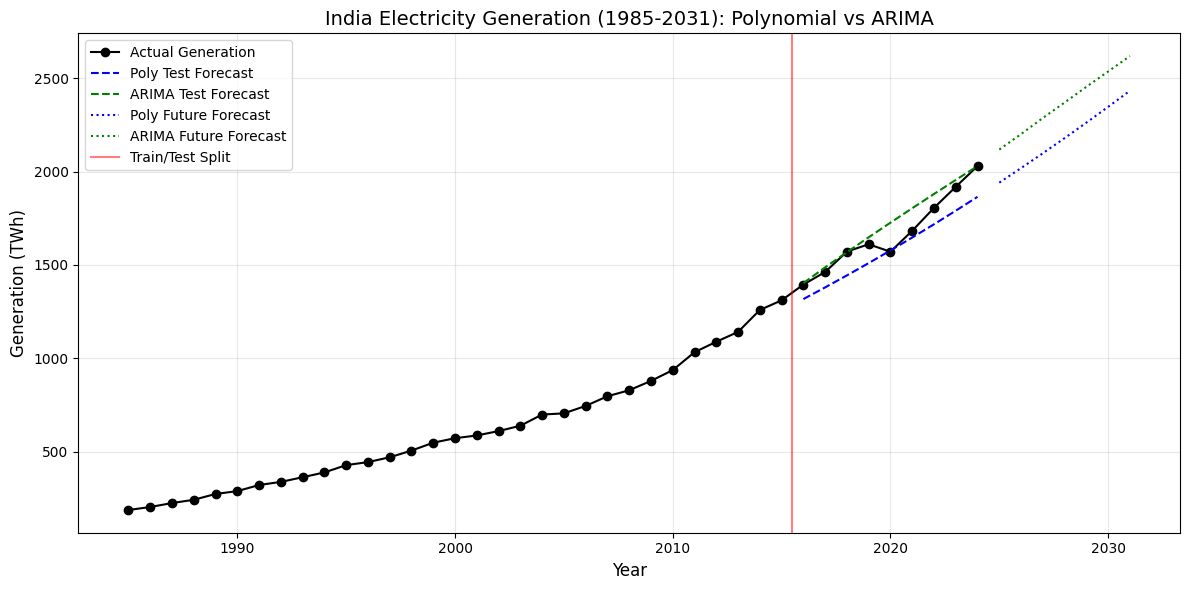

In [ ]:
# 7. Visualization
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(df['Year'], df['Value'], 'ko-', label='Actual Generation')

# Plot Test predictions
plt.plot(test['Year'], y_test_pred_poly, 'b--', label='Poly Test Forecast')
plt.plot(test['Year'], y_test_pred_arima, 'g--', label='ARIMA Test Forecast')

# Plot Future predictions
plt.plot(future_years_df['Year'], future_pred_poly, 'b:', label='Poly Future Forecast')
plt.plot(future_years_df['Year'], future_pred_arima, 'g:', label='ARIMA Future Forecast')

# Add vertical line for train/test split
plt.axvline(x=2015.5, color='red', linestyle='-', alpha=0.5, label='Train/Test Split')

plt.title('India Electricity Generation (1985-2031): Polynomial vs ARIMA', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Generation (TWh)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()